In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('bmi.csv')
df = df.head(100)
df

,height,weight,label
0,142,62,fat
1,142,73,fat
2,177,61,normal
3,187,48,thin
4,153,60,fat
...,...,...,...
95,136,51,fat
96,131,37,normal
97,180,75,normal
98,191,60,thin


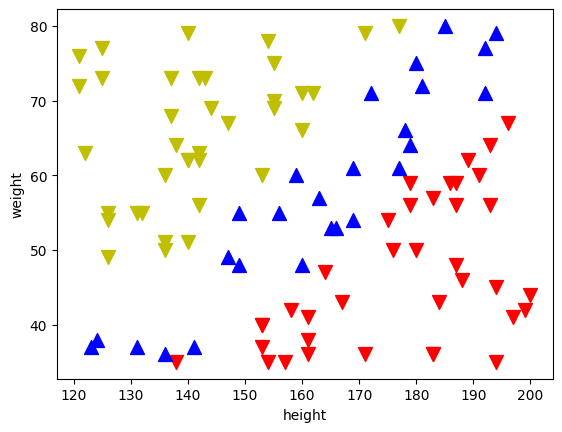

In [3]:
plt.scatter(df.iloc[df["label"] == "thin", 0], df.iloc[df["label"] == "thin", 1], s=100, marker="v", c="r")
plt.scatter(df.iloc[df["label"] == "normal", 0], df.iloc[df["label"] == "normal", 1], s=100, marker="^", c="b")
plt.scatter(df.iloc[df["label"] == "fat", 0], df.iloc[df["label"] == "fat", 1], s=100, marker="v", c="y")
plt.xlabel('height')
plt.ylabel('weight')
plt.show()

In [4]:
model = KMeans(n_clusters=3, init="random", random_state = 42)
model.fit(df.iloc[:,:2])
model.cluster_centers_

array([[152.14285714,  43.53571429],
       [184.71052632,  58.28947368],
       [139.73529412,  65.32352941]])

In [5]:
pred = model.predict(df.iloc[:,:2])
pred

array([2, 2, 1, 1, 2, 1, 0, 1, 1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 2, 1,
       0, 0, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 2, 0, 1, 1, 2, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 2, 2, 1, 2, 1, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 2, 1, 2, 0, 0, 1, 2, 2, 0, 2, 1, 2, 2, 2, 1,
       2, 0, 2, 1, 0, 1, 1, 2, 0, 1, 1, 2])

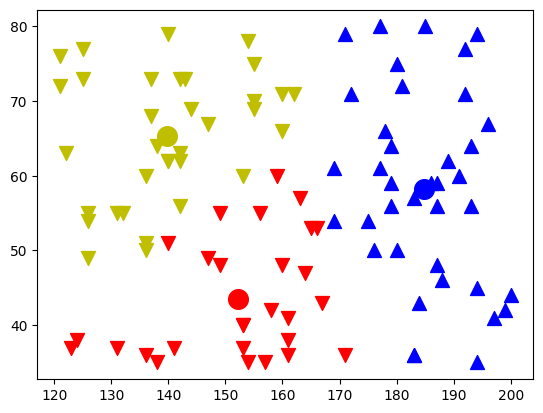

In [6]:
c0, c1, c2 = model.cluster_centers_
plt.scatter(df.iloc[model.labels_ == 0, 0], df.iloc[model.labels_ == 0, 1], s=100, marker="v", c="r")
plt.scatter(df.iloc[model.labels_ == 1, 0], df.iloc[model.labels_ == 1, 1], s=100, marker="^", c="b")
plt.scatter(df.iloc[model.labels_ == 2, 0], df.iloc[model.labels_ == 2, 1], s=100, marker="v", c="y")
plt.scatter(c0[0], c0[1], s=200, c="r")
plt.scatter(c1[0], c1[1], s=200, c="b")
plt.scatter(c2[0], c2[1], s=200, c="y")
plt.show()

In [7]:
def plot_clusters(model, data):
    c0, c1, c2 = model.cluster_centers_
    plt.scatter(df.iloc[model.labels_ == 0, 0], df.iloc[model.labels_ == 0, 1], s=100, marker="v", c="r")
    plt.scatter(df.iloc[model.labels_ == 1, 0], df.iloc[model.labels_ == 1, 1], s=100, marker="^", c="b")
    plt.scatter(df.iloc[model.labels_ == 2, 0], df.iloc[model.labels_ == 2, 1], s=100, marker="v", c="y")
    plt.scatter(c0[0], c0[1], s=200, c="r")
    plt.scatter(c1[0], c1[1], s=200, c="b")
    plt.scatter(c2[0], c2[1], s=200, c="y")

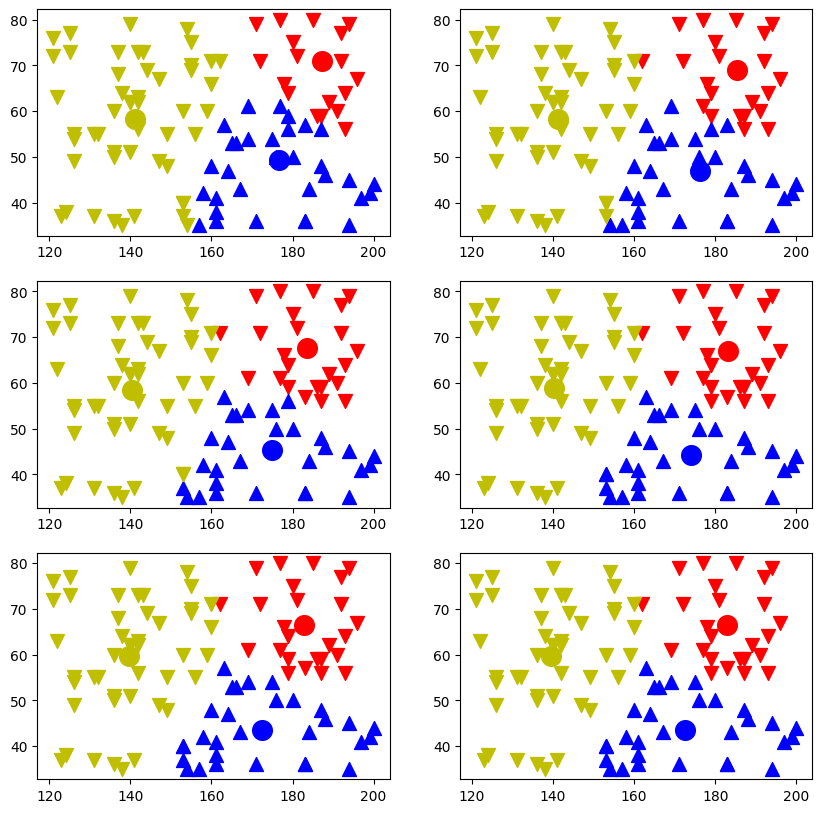

In [8]:
plt.figure(figsize=(10,10))

model1 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=1, random_state=1)
model1.fit(df.iloc[:,:2])
plt.subplot(3,2,1)
plot_clusters(model1,df.iloc[:,:2])

model2 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=2, random_state=1)
model2.fit(df.iloc[:,:2])
plt.subplot(3,2,2)
plot_clusters(model2,df.iloc[:,:2])

model3 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=3, random_state=1)
model3.fit(df.iloc[:,:2])
plt.subplot(3,2,3)
plot_clusters(model3,df.iloc[:,:2])

model4 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=4, random_state=1)
model4.fit(df.iloc[:,:2])
plt.subplot(3,2,4)
plot_clusters(model4,df.iloc[:,:2])

model5 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=5, random_state=1)
model5.fit(df.iloc[:,:2])
plt.subplot(3,2,5)
plot_clusters(model5,df.iloc[:,:2])

model6 = KMeans(n_clusters=3, init="random", n_init=1, max_iter=6, random_state=1)
model6.fit(df.iloc[:,:2])
plt.subplot(3,2,6)
plot_clusters(model6,df.iloc[:,:2])
plt.show()

In [9]:
ac = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
labels = ac.fit_predict(df.iloc[:,:2])
print("클러스터 분류 결과 :", labels)

클러스터 분류 결과 : [1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 0
 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 1 0 0 1
 0 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0 0 0 1 1 0 0 1]


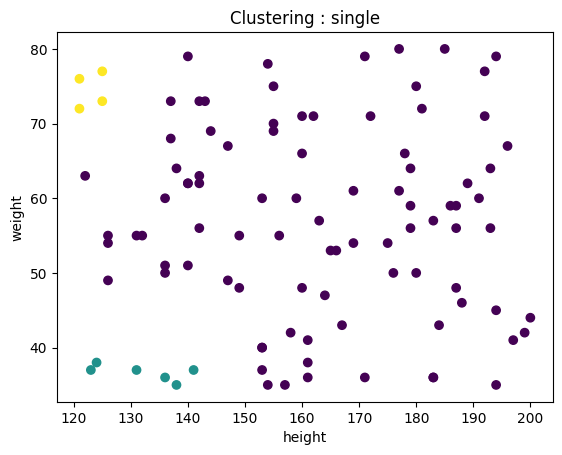

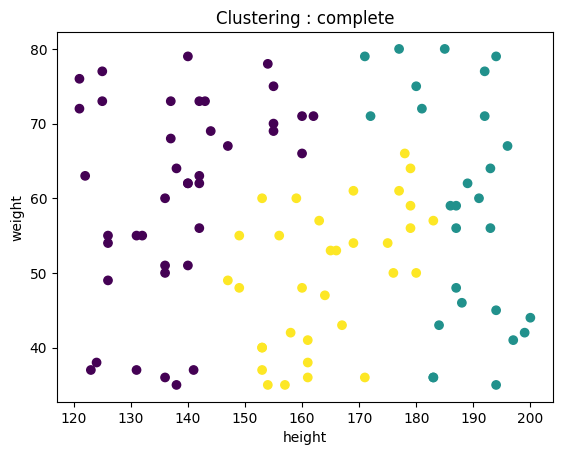

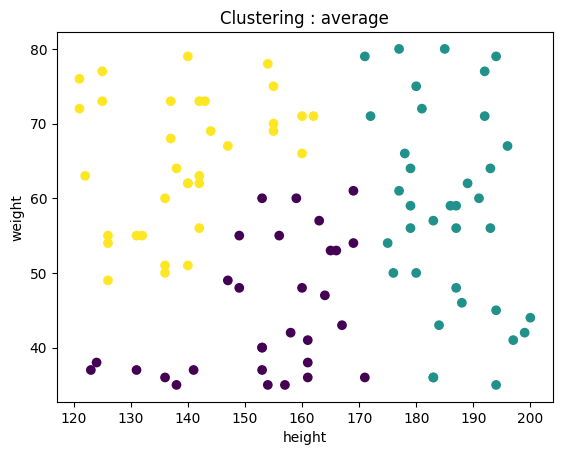

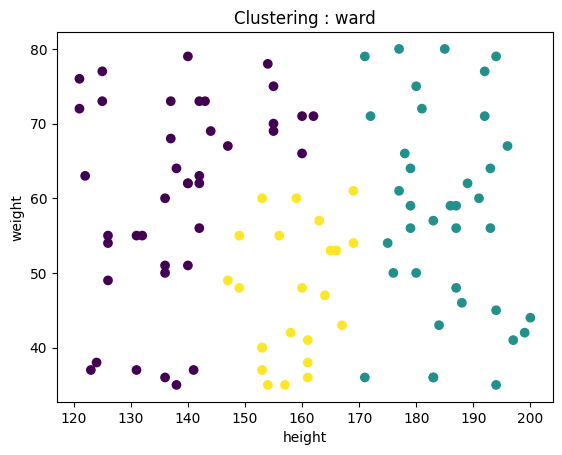

In [10]:
linkage = ["single", "complete", "average", "ward"]
for idx, i in enumerate(linkage):
    plt.figure(idx)
    hier = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=i)
    hier.fit(df.iloc[:,:2])
    # print(hier.labels_)
    plt.scatter(df.iloc[:,0], df.iloc[:,1], c=hier.labels_)
    plt.title('Clustering : '+i)
    plt.xlabel('height')
    plt.ylabel('weight')
plt.show()